In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns #visualization
import matplotlib.pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/spaceship-titanic/sample_submission.csv
/kaggle/input/spaceship-titanic/train.csv
/kaggle/input/spaceship-titanic/test.csv


<center style="font-family:verdana;"><h1 style="font-size:200%; padding: 10px; background: #001f3f;"><b style="color:orange;">Titanic Spaceship UMAP. GPU in ON!</b></h1></center>

UMAP: Uniform Manifold Approximation and Projection for Dimension Reduction

"Uniform Manifold Approximation and Projection (UMAP) is a dimension reduction technique that can be used for visualisation similarly to t-SNE, but also for general non-linear dimension reduction. The algorithm is founded on three assumptions about the data."

The data is uniformly distributed on Riemannian manifold;

The Riemannian metric is locally constant (or can be approximated as such);

The manifold is locally connected.

https://umap-learn.readthedocs.io/en/latest/

In [1]:
import cudf, cuml
import cupy as cp

from cuml.manifold import TSNE, UMAP
import matplotlib.pyplot as plt
from matplotlib.pyplot import ylim, xlim
%matplotlib inline

In [4]:
df = pd.read_csv('../input/spaceship-titanic/train.csv')
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [5]:
columns = df.columns
columns

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name', 'Transported'],
      dtype='object')

In [6]:
df[columns].head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [9]:
from sklearn.preprocessing import LabelEncoder

#fill in mean for floats
for c in df.columns:
    if df[c].dtype=='float16' or  df[c].dtype=='float32' or  df[c].dtype=='float64':
        df[c].fillna(df[c].mean())

#fill in -999 for categoricals
df = df.fillna(-999)
# Label Encoding
for f in df.columns:
    if df[f].dtype=='object': 
        lbl = LabelEncoder()
        lbl.fit(list(df[f].values))
        df[f] = lbl.transform(list(df[f].values))
        
print('Labelling done.')

Labelling done.


#Checking the Encoding

In [10]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0,2,1,150,3,39.0,1,0.0,0.0,0.0,0.0,0.0,5253,False
1,1,1,1,2185,3,24.0,1,109.0,9.0,25.0,549.0,44.0,4503,True
2,2,2,1,2,3,58.0,2,43.0,3576.0,0.0,6715.0,49.0,458,False
3,3,2,1,2,3,33.0,1,0.0,1283.0,371.0,3329.0,193.0,7150,False
4,4,1,1,2187,3,16.0,1,303.0,70.0,151.0,565.0,2.0,8320,True


In [11]:
%%time
tsne = TSNE(n_components=2)
df_2D = tsne.fit_transform(df[columns].values)

CPU times: user 1.76 s, sys: 777 ms, total: 2.54 s
Wall time: 3.19 s


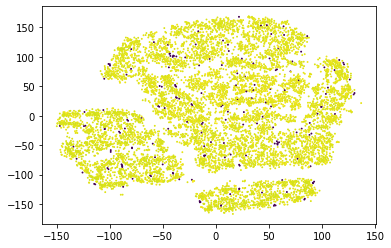

In [12]:
plt.scatter(df_2D[:,0], df_2D[:,1], c=df['Age'].values, s = 0.8);

In [13]:
%%time
umap = UMAP(n_components=2)
df_2D = umap.fit_transform(df[columns].values)

CPU times: user 260 ms, sys: 253 ms, total: 514 ms
Wall time: 861 ms


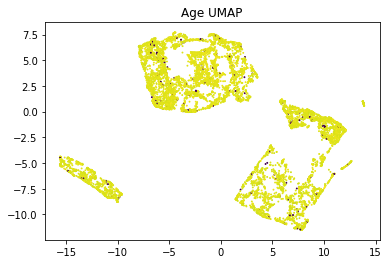

In [31]:
plt.scatter(df_2D[:,0], df_2D[:,1], c=df['Age'].values, s = 0.8)
plt.title('Age UMAP');

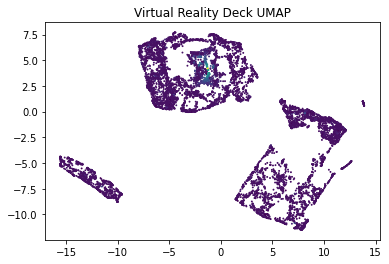

In [30]:
plt.scatter(df_2D[:,0], df_2D[:,1], c=df['VRDeck'].values, s = 0.8)
plt.title('Virtual Reality Deck UMAP');

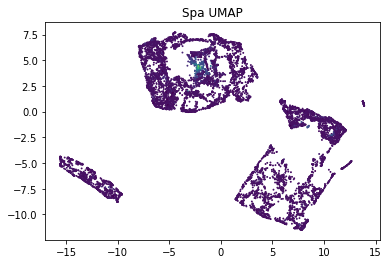

In [29]:
plt.scatter(df_2D[:,0], df_2D[:,1], c=df['Spa'].values, s = 0.8)
plt.title('Spa UMAP');

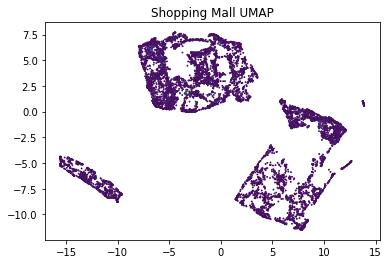

In [28]:
plt.scatter(df_2D[:,0], df_2D[:,1], c=df['ShoppingMall'].values, s = 0.8)
plt.title('Shopping Mall UMAP');

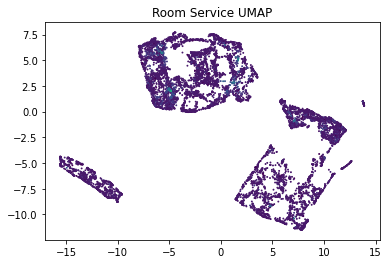

In [27]:
plt.scatter(df_2D[:,0], df_2D[:,1], c=df['RoomService'].values, s = 0.8)
plt.title('Room Service UMAP');

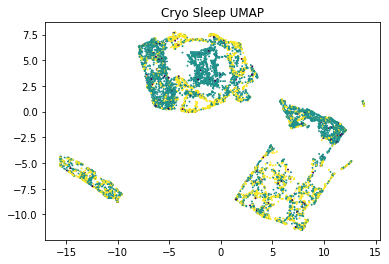

In [26]:
plt.scatter(df_2D[:,0], df_2D[:,1], c=df['CryoSleep'].values, s = 0.8)
plt.title('Cryo Sleep UMAP');

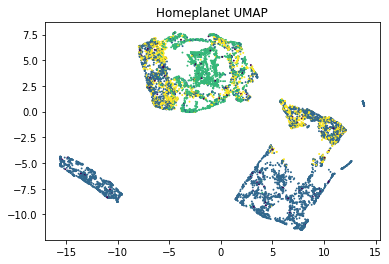

In [25]:
plt.scatter(df_2D[:,0], df_2D[:,1], c=df['HomePlanet'].values, s = 0.8)
plt.title('Homeplanet UMAP');

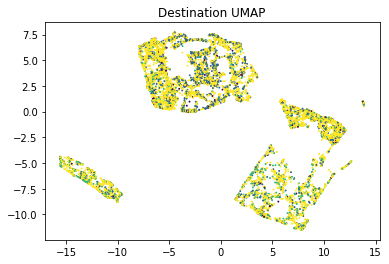

In [24]:
plt.scatter(df_2D[:,0], df_2D[:,1], c=df['Destination'].values, s = 0.8)
plt.title('Destination UMAP');

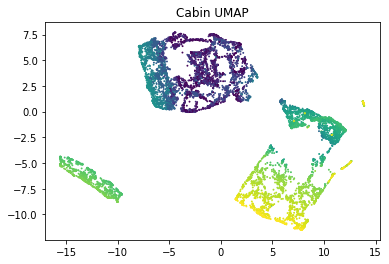

In [23]:
plt.scatter(df_2D[:,0], df_2D[:,1], c=df['Cabin'].values, s = 0.8)
plt.title('Cabin UMAP');

#Acknowledgement:

Bojan Tunguz

In [ ]:
#Code by Olga Belitskaya https://www.kaggle.com/olgabelitskaya/sequential-data/comments
from IPython.display import display,HTML
c1,c2,f1,f2,fs1,fs2=\
'#eb3434','#eb3446','Akronim','Smokum',30,15
def dhtml(string,fontcolor=c1,font=f1,fontsize=fs1):
    display(HTML("""<style>
    @import 'https://fonts.googleapis.com/css?family="""\
    +font+"""&effect=3d-float';</style>
    <h1 class='font-effect-3d-float' style='font-family:"""+\
    font+"""; color:"""+fontcolor+"""; font-size:"""+\
    str(fontsize)+"""px;'>%s</h1>"""%string))
    
    
dhtml('Thanks Bojan Tunguz for the script' )